In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
# Selecting the brain region
select_region = "Isocortex-1"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 227670 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [4]:
# Define the category to remove
excluded_groups = ["27 MY GABA", "10 LSX GABA", "15 HY Gnrh1 Glut"]

# Filter out the cells belonging to the specified category
adata = adata[~adata.obs["class"].isin(excluded_groups)].copy()

print(f"Cells belonging to category '{excluded_groups}' have been removed.")
adata

Cells belonging to category '['27 MY GABA', '10 LSX GABA', '15 HY Gnrh1 Glut']' have been removed.


AnnData object with n_obs × n_vars = 227667 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [5]:
gene_names_df = adata.var.copy()
adata.var.set_index("gene_symbol", inplace=True)

**Differential Expression**

In [6]:
# Preprocess the data
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(adata)  # Log-transform the data
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)  # Select highly variable genes

In [21]:
def run_real_DE(adata, groupby="class", method="wilcoxon"):
    """
    Run differential expression analysis and return the results.
    """
    sc.tl.rank_genes_groups(adata, groupby=groupby, method=method, use_raw=False)
    return adata.uns["rank_genes_groups"].copy()

In [27]:
real_result = run_real_DE(adata, groupby="class")

In [18]:
# Perform differential expression analysis
group_by="class"
sc.tl.rank_genes_groups(
    adata,
    groupby=group_by,
    method="wilcoxon",
    use_raw=False
)

In [ ]:
# Extract the differential expression results
deg_results = pd.DataFrame({
    group: pd.DataFrame(adata.uns["rank_genes_groups"]["names"])[group]
    for group in adata.uns["rank_genes_groups"]["names"].dtype.names
})

# # Save the dataframe to a CSV file
# output_path = base_path / "outputs/DEG/" / f"WMB-10Xv3-{select_region}-DEG-{group_by}.csv"
# deg_results.to_csv(output_path, index=False)

# print(f"Differentially expressed genes saved to {output_path}")

## Visualization

In [9]:
deg_results.head()

,01 IT-ET Glut,02 NP-CT-L6b Glut,03 OB-CR Glut,04 DG-IMN Glut,05 OB-IMN GABA,06 CTX-CGE GABA,07 CTX-MGE GABA,08 CNU-MGE GABA,09 CNU-LGE GABA,11 CNU-HYa GABA,...,13 CNU-HYa Glut,14 HY Glut,16 HY MM Glut,24 MY Glut,25 Pineal Glut,30 Astro-Epen,31 OPC-Oligo,32 OEC,33 Vascular,34 Immune
0,C1ql3,Hs3st4,Dach1,Zbtb20,H3f3b,Adarb2,Kcnc2,Sox2ot,Pbx3,Gad2,...,Htr2c,C130073E24Rik,Foxb1,Hoxa5,Gm44196,Plpp3,Olig1,Apod,Sparc,Laptm5
1,Cck,Cdh18,Tmem163,Frmd4b,Zbtb20,Dlx6os1,Rab3b,Alk,Foxp2,Slc32a1,...,Nnat,Cmss1,Lhx1,Hoxb5,Rbp3,Slc1a3,Qk,Sntb1,Utrn,Inpp5d
2,Tafa1,Foxp2,Reln,Thsd7a,Msi2,Gad1,Slc32a1,Nkain3,Gad2,Nhs,...,Cntnap5b,Nnat,Dgkb,Ntng1,Tulp1,Slc1a2,Gjc3,Plce1,Zbtb20,Cst3
3,Bdnf,Nxph3,Msi2,Grik2,Sox4,Erbb4,Nxph1,Crhbp,Adarb2,Gad1,...,Tmem163,Rmst,Rmst,Ndst4,Otx2os1,Mt1,Sox10,Ptn,Epas1,Serinc3
4,Nrgn,Rprm,Trp73,Prox1,Ttc28,Zfp536,Grip1,Npy,Gad1,Erbb4,...,Rbms3,Dpyd,Zfhx3,Gm12239,Cngb3,Gja1,Bcas1,Kctd12,Gng5,Csf1r


# Validation

## Statistical robustness
To perform a permutation test via label shuffling, the idea is to:

* Shuffle the "class" labels in .obs
* Run DE analysis on the shuffled labels
* Collect top DE genes or statistics (e.g., adjusted p-values or log fold changes)
* Repeat this process multiple times (e.g., 100–1000 permutations)
* Compare your real DEGs to this null distribution to assess how likely they are to arise by chance

In [22]:
def single_permutation_DE(adata, groupby, method, top_n_genes, seed, target_groups=None):
    """
    Perform DE on a shuffled version of the dataset.
    """
    np.random.seed(seed)
    adata_perm = adata.copy()
    shuffled_labels = np.random.permutation(adata_perm.obs[groupby].values)
    adata_perm.obs["shuffled_labels"] = shuffled_labels

    sc.tl.rank_genes_groups(
        adata_perm,
        groupby="shuffled_labels",
        method=method,
        use_raw=False,
        groups=target_groups
    )
    
    de_result = adata_perm.uns["rank_genes_groups"]
    genes = []

    for group in de_result["names"].dtype.names:
        top_genes = de_result["names"][group][:top_n_genes]
        genes.extend(top_genes)

    return genes

In [ ]:
from multiprocessing import Pool, cpu_count
from functools import partial

def single_permutation_DE(adata, groupby, method, top_n_genes, seed, target_groups=None):
    """
    Run one permutation of DE by shuffling group labels, with group size checks.
    """
    np.random.seed(seed)
    adata_perm = adata.copy()
    shuffled_labels = np.random.permutation(adata_perm.obs[groupby].values)
    adata_perm.obs["shuffled_labels"] = shuffled_labels

    # Check that all target groups exist and are non-empty
    available_groups = adata_perm.obs["shuffled_labels"].unique()
    if target_groups:
        if any(g not in available_groups for g in target_groups):
            return []  # Skip if any target group is missing
    else:
        # If comparing all groups, require at least 2 unique groups
        if len(available_groups) < 2:
            return []

    # Run DE
    sc.tl.rank_genes_groups(
        adata_perm,
        groupby="shuffled_labels",
        method=method,
        use_raw=False,
        groups=target_groups if target_groups else None
    )

    # Collect top genes from all target groups
    de_result = adata_perm.uns["rank_genes_groups"]
    genes = []
    for group in de_result["names"].dtype.names:
        top_genes = de_result["names"][group][:top_n_genes]
        genes.extend(top_genes)

    return genes


In [31]:
gene_counts, n_groups = permute_DE_test_parallel(
    adata, groupby="class", n_permutations=100, top_n_genes=100
)

IndexError: list index out of range

In [24]:
def compute_empirical_pvals(top_real_genes, gene_counts, n_permutations, n_groups):
    """
    Calculate empirical p-values for top real DEGs.
    """
    max_possible = n_permutations * n_groups
    empirical_pvals = {
        gene: (gene_counts.get(gene, 0) + 1) / (max_possible + 1)
        for gene in top_real_genes
    }
    return empirical_pvals

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_permutation_frequencies(top_real_genes, gene_counts, n_permutations, n_groups, group_label):
    """
    Barplot showing how often top DEGs appear in null permutations.
    """
    max_possible = n_permutations * n_groups
    counts = [gene_counts.get(gene, 0) for gene in top_real_genes]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=counts, y=top_real_genes)
    plt.xlabel("Occurrences in Permutations")
    plt.ylabel("Top Real DE Genes")
    plt.title(f"Permutation Frequency of Top DEGs ({group_label})\n(Max possible = {max_possible})")
    plt.tight_layout()
    plt.show()


In [ ]:
def plot_empirical_vs_adjusted_pvals(top_real_genes, empirical_pvals, adjusted_pvals, group_label):
    """
    Scatter plot comparing empirical and adjusted p-values.
    """
    empirical = [empirical_pvals[gene] for gene in top_real_genes]
    adjusted = [adjusted_pvals[gene] for gene in top_real_genes]

    plt.figure(figsize=(6, 6))
    plt.scatter(empirical, adjusted)
    plt.plot([0, 1], [0, 1], "r--")
    plt.xlabel("Empirical p-value (permutation)")
    plt.ylabel("Adjusted p-value (Scanpy)")
    plt.title(f"Empirical vs Adjusted p-values ({group_label})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [29]:
group = "34 Immune"
top_real_genes = list(real_result["names"][group][:20])
empirical_pvals = compute_empirical_pvals(
    top_real_genes, gene_counts, n_permutations=100, n_groups=n_groups)

NameError: name 'n_groups' is not defined

In [ ]:
plot_permutation_frequencies(top_real_genes, gene_counts, 100, n_groups, group_label=group)

In [ ]:
adjusted_pvals_map = {
    gene: real_result["pvals_adj"][group][i]
    for i, gene in enumerate(top_real_genes)
}

plot_empirical_vs_adjusted_pvals(top_real_genes, empirical_pvals, adjusted_pvals_map, group_label=group)

In [13]:
# Run it on your AnnData object (make sure it's preprocessed)
gene_counts = permute_DE_test_parallel(adata, groupby="class", n_permutations=100)

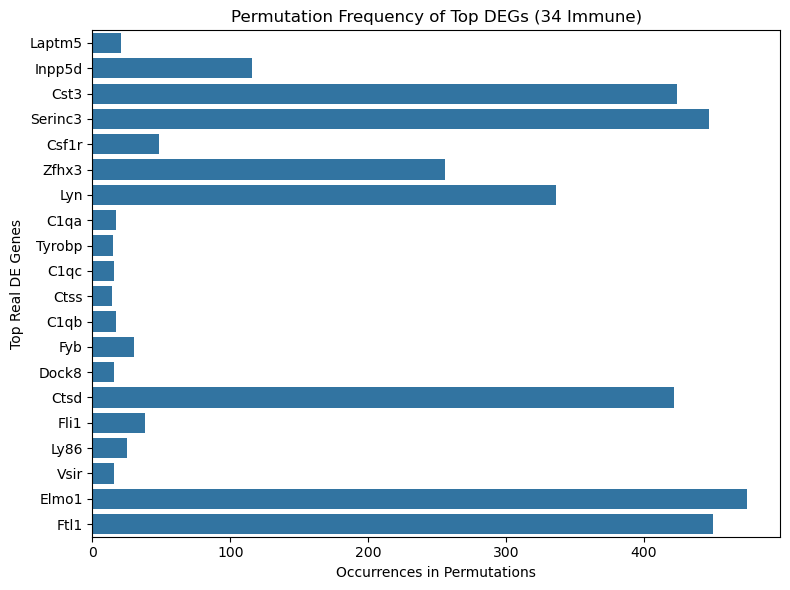

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


group = "34 Immune"
top_real_genes = list(real_deg_result["names"][group][:20])

# Get permutation counts for each
counts = [gene_counts.get(gene, 0) for gene in top_real_genes]

# Plot
plt.figure(figsize=(8, 6))
sns.barplot(x=counts, y=top_real_genes)
plt.xlabel("Occurrences in Permutations")
plt.ylabel("Top Real DE Genes")
plt.title(f"Permutation Frequency of Top DEGs ({group})")
plt.tight_layout()
plt.show()


In [16]:
adata.uns["rank_genes_groups"]

{'params': {'groupby': 'shuffled_labels',
  'reference': 'rest',
  'method': 'wilcoxon',
  'use_raw': False,
  'layer': None,
  'corr_method': 'benjamini-hochberg'}}

### UMAP: expression of top DEGs in one cluster

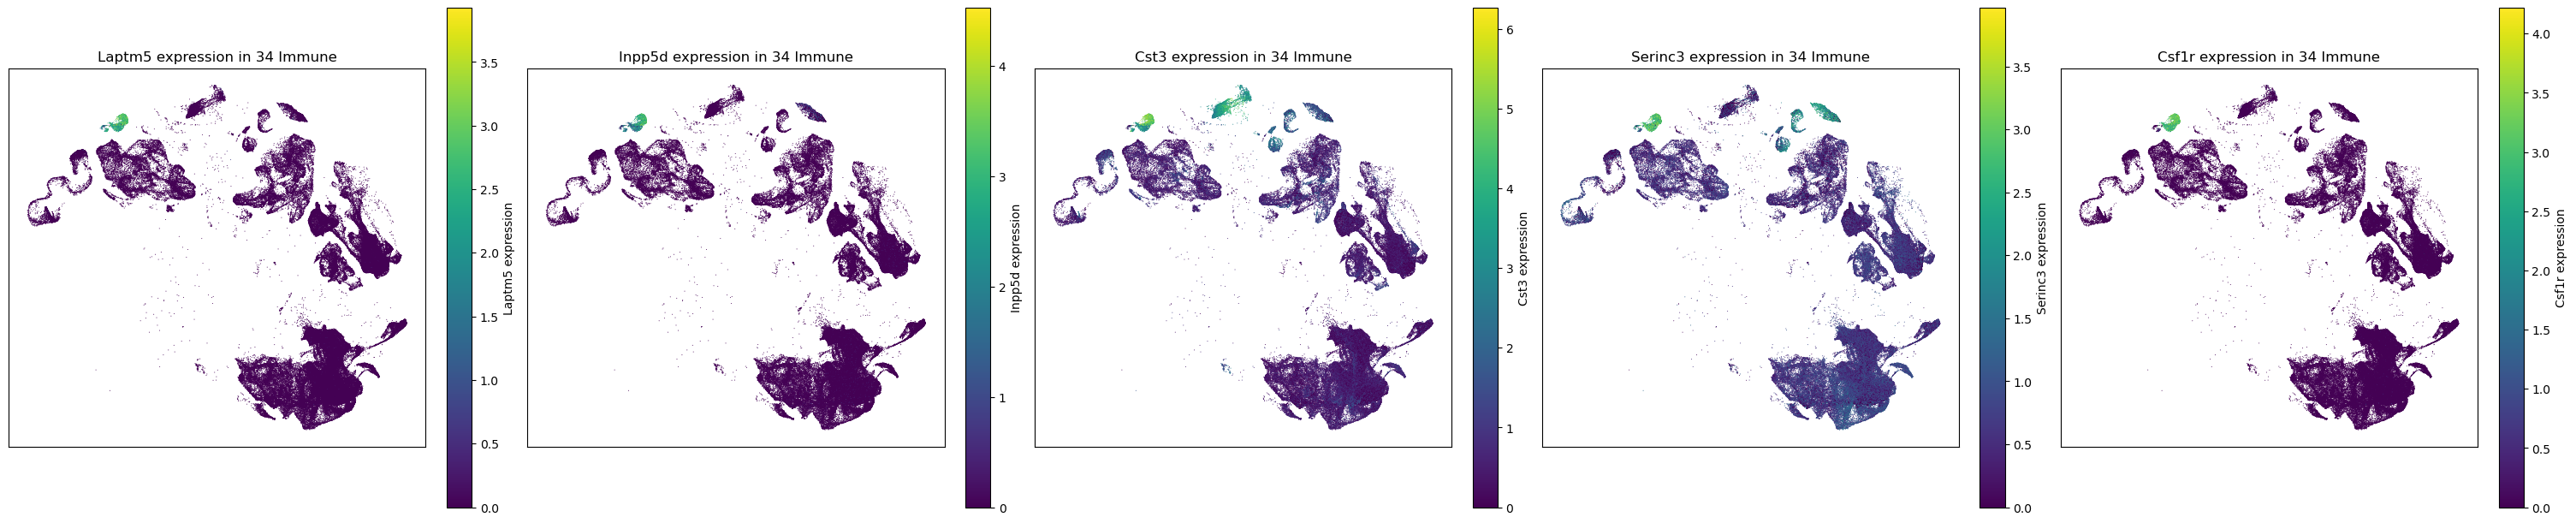

In [10]:
# Select a group and get the top 5 genes
group = "34 Immune"
top_genes = deg_results[group].head(5)

# Create a figure with subplots
fig, axes = plt.subplots(1, len(top_genes), figsize=(6 * len(top_genes), 6), constrained_layout=True)

# If there's only one gene, make sure axes is iterable
if len(top_genes) == 1:
    axes = [axes]

# Plot the expression of each gene using UMAP coordinates from adata.obs
for ax, gene in zip(axes, top_genes):
    scatter = ax.scatter(
        adata.obs["x"],
        adata.obs["y"],
        c=adata[:, gene].X.toarray().flatten(),
        cmap="viridis",
        s=0.5,
        edgecolor="none"
    )
    fig.colorbar(scatter, ax=ax, label=f"{gene} expression")
    ax.set_title(f"{gene} expression in {group}")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

plt.show()

### Heatmap: expression of top DEGs across clusters - cluster level

In [16]:
def plot_top_deg_expression_heatmap(adata, deg_results, group_by, n_top_genes=1, agg_func="median"):
    """
    Plot a heatmap of aggregated expression values (mean or median) of top DEGs across clusters.

    Parameters:
    - adata: AnnData object
    - deg_results: DataFrame where each column corresponds to a cluster and contains ranked DEG gene names
    - group_by: Column in adata.obs used to group cells (e.g., "leiden", "louvain")
    - n_top_genes: Number of top genes to include per cluster
    - agg_func: Aggregation function to use, either "median" or "mean"
    """
    if agg_func not in ["median", "mean"]:
        raise ValueError("agg_func must be 'median' or 'mean'")

    # Extract top genes per cluster
    top_deg_genes = []
    gene_cluster_mapping = {}
    for cluster in deg_results.columns:
        cluster_top_genes = deg_results[cluster].dropna().head(n_top_genes).tolist()
        top_deg_genes.extend(cluster_top_genes)
        for gene in cluster_top_genes:
            gene_cluster_mapping[gene] = cluster

    top_deg_genes = list(set(top_deg_genes))  # Remove duplicates

    # Aggregate expression by group
    expression_df = adata[:, top_deg_genes].to_df()
    grouped = expression_df.groupby(adata.obs[group_by])

    if agg_func == "mean":
        aggregated_expression = grouped.mean()
    else:  # median
        aggregated_expression = grouped.median()

    # Maintain cluster order if categorical
    if hasattr(adata.obs[group_by], "cat"):
        cluster_order = adata.obs[group_by].cat.categories
        aggregated_expression = aggregated_expression.loc[cluster_order]
    else:
        cluster_order = aggregated_expression.index.tolist()

    # Order genes based on their original cluster association
    ordered_genes = []
    for cluster in cluster_order:
        cluster_genes = [gene for gene in top_deg_genes if gene_cluster_mapping.get(gene) == cluster]
        ordered_genes.extend(cluster_genes)
    
    aggregated_expression = aggregated_expression[ordered_genes]

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        aggregated_expression.T,
        cmap="viridis",
        cbar_kws={"label": f"{agg_func.capitalize()} Expression"},
        xticklabels=True,
        yticklabels=ordered_genes
    )
    plt.xlabel("Clusters")
    plt.ylabel("Genes")
    plt.title(f"{agg_func.capitalize()} Expression of Top {n_top_genes} DEGs per Cluster")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_122641/520071919.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = expression_df.groupby(adata.obs[group_by])


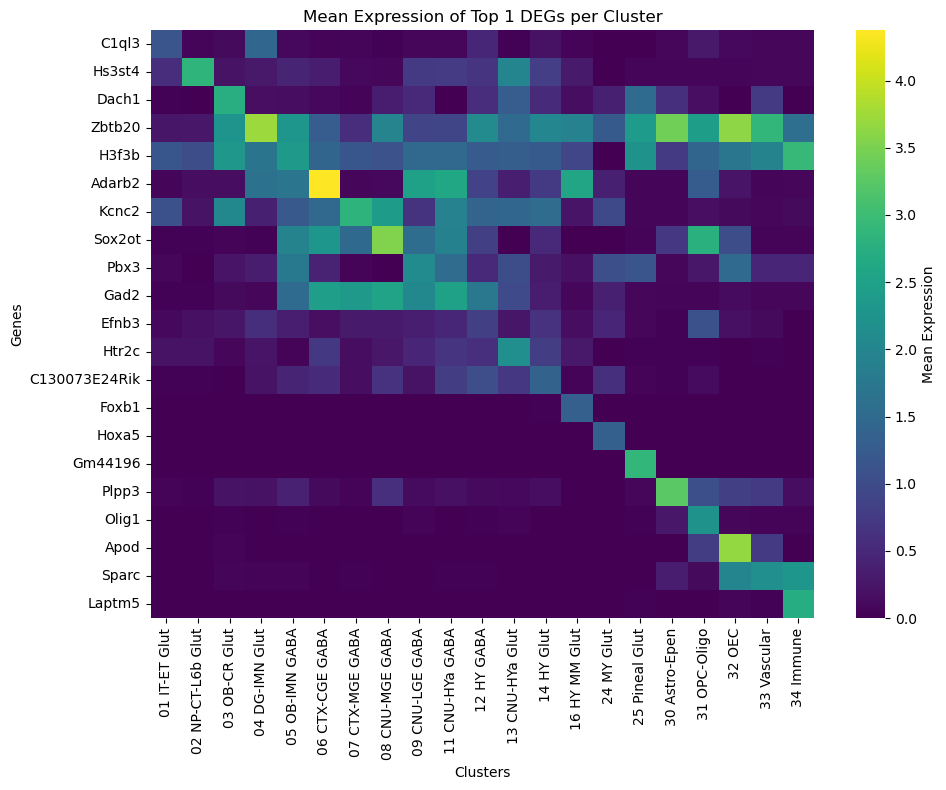

In [17]:
plot_top_deg_expression_heatmap(
    adata=adata,
    deg_results=deg_results,
    group_by="class",
    n_top_genes=1,
    agg_func="mean"
)

### Heatmap: expression of top DEGs across clusters - cell level

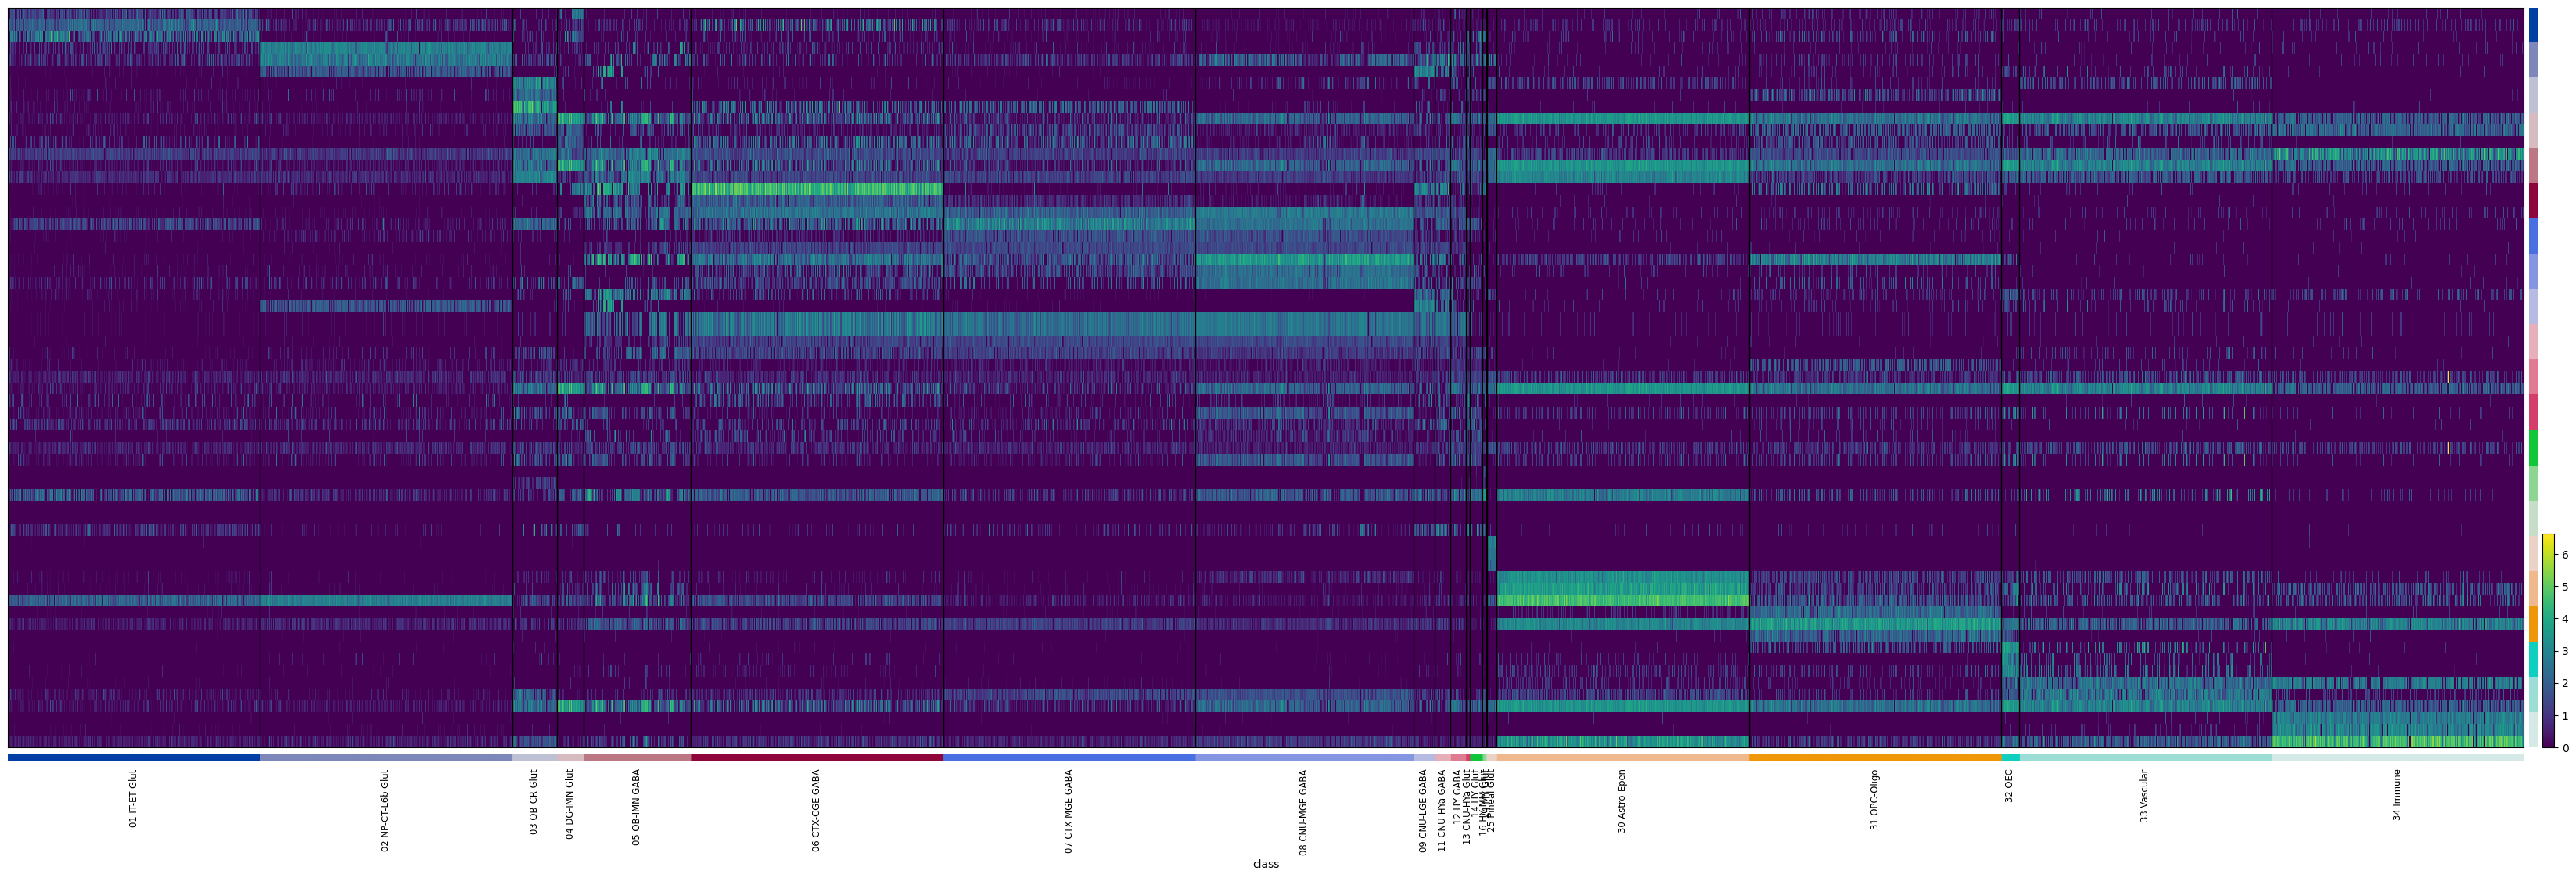

In [15]:
# Define the number of top genes to include per group
n_top_genes = 3

# Extract the top genes for all groups and separate them by group
top_genes_for_heatmap = []
var_group_positions = []
var_group_labels = []
start_idx = 0

for group in deg_results.columns:
    if not deg_results[group].empty:
        group_genes = deg_results[group].dropna().head(n_top_genes).tolist()
        if group_genes:  # Ensure the group has genes
            top_genes_for_heatmap.extend(group_genes)
            var_group_positions.append((start_idx, start_idx + len(group_genes) - 1))
            var_group_labels.append(group)
            start_idx += len(group_genes)

# Compute group sizes
group_sizes = adata.obs[group_by].value_counts()

# Compute scaling factors (normalize based on the largest group)
max_group_size = group_sizes.max() if len(group_sizes) > 0 else 1
scaling_factors = group_sizes / max_group_size  # This replicates your previous calculation

# Store the scaling factors in the AnnData object
adata.obs["scaled_group"] = adata.obs[group_by].map(scaling_factors)

# Downsample cells in large groups to balance the heatmap
max_cells_per_group = 500  # Set a maximum number of cells to display per group

downsampled_indices = []
for group, size in group_sizes.items():
    group_indices = adata.obs[adata.obs[group_by] == group].index.to_list()
    if size > max_cells_per_group:
        sampled_indices = np.random.choice(group_indices, max_cells_per_group, replace=False)
        downsampled_indices.extend(sampled_indices)
    else:
        downsampled_indices.extend(group_indices)

# Ensure correct indexing before subsetting
adata_downsampled = adata[downsampled_indices].copy()

# Adjust the figure size dynamically based on the number of groups and genes
fig_width = max(10, len(var_group_labels) * 2)  # Minimum width of 10, scale with groups
fig_height = max(8, len(top_genes_for_heatmap) * 0.2)  # Minimum height of 8, scale with genes

# Ensure there are genes before plotting
if top_genes_for_heatmap:
    sc.pl.heatmap(
        adata_downsampled,
        var_names=top_genes_for_heatmap,
        groupby=group_by,
        cmap="viridis",
        swap_axes=True,
        figsize=(fig_width, fig_height),
        dendrogram=False,
        var_group_positions=var_group_positions,
        var_group_labels=var_group_labels,
        show=True
    )
else:
    print("No genes selected for the heatmap.")


## Modules

In [18]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_Isocortex-M1,kME_Isocortex-M2,kME_Isocortex-M3,kME_Isocortex-M4,kME_grey,kME_Isocortex-M5,kME_Isocortex-M6,kME_Isocortex-M7,kME_Isocortex-M8,kME_Isocortex-M9
ENSMUSG00000015090,ENSMUSG00000015090,Isocortex-M1,yellow,0.645442,-0.082131,0.055263,0.123491,-0.087391,0.096088,0.129945,0.244009,0.606363,-0.205105
ENSMUSG00000031425,ENSMUSG00000031425,Isocortex-M1,yellow,0.919267,-0.107151,0.070567,0.095239,-0.112462,0.107643,0.243849,0.051845,0.041710,-0.244151
ENSMUSG00000115529,ENSMUSG00000115529,Isocortex-M1,yellow,0.290416,-0.025055,0.009020,0.027299,-0.029463,0.038628,0.236592,0.012456,0.003026,-0.099603
ENSMUSG00000029819,ENSMUSG00000029819,Isocortex-M2,turquoise,-0.003594,0.542115,0.002021,-0.003075,-0.085746,-0.004960,0.046668,0.012330,0.004241,-0.161405
ENSMUSG00000024610,ENSMUSG00000024610,Isocortex-M3,blue,0.006335,-0.033054,0.153545,0.040280,-0.027896,0.001917,-0.002614,0.018507,0.042056,-0.035275


### Heatmap: kME of hub genes across modules

In [19]:
n_top_genes_per_module = 2  # Set the number of top genes to select per module

# Create an empty list to store dataframes for each module
top_genes_by_module = []

# Iterate through each unique module in the "module" column
for module_name in modules_df["module"].unique():
    # Filter the dataframe for the current module
    module_genes = modules_df[modules_df["module"] == module_name]
    
    # Sort the genes by the corresponding kME column in descending order
    sorted_genes = module_genes.sort_values(by=f"kME_{module_name}", ascending=False)
    
    # Select the top genes (you can adjust the number of top genes as needed)
    top_genes = sorted_genes.head(n_top_genes_per_module)
    
    # Append the top genes dataframe to the list
    top_genes_by_module.append(top_genes)

# Combine all the top genes dataframes into a single dataframe
top_genes_df = pd.concat(top_genes_by_module, ignore_index=True)

# Display the resulting dataframe
top_genes_df.head()

,gene_name,module,color,kME_Isocortex-M1,kME_Isocortex-M2,kME_Isocortex-M3,kME_Isocortex-M4,kME_grey,kME_Isocortex-M5,kME_Isocortex-M6,kME_Isocortex-M7,kME_Isocortex-M8,kME_Isocortex-M9
0,ENSMUSG00000033579,Isocortex-M1,yellow,0.931046,-0.094431,0.014312,0.035500,-0.096881,0.045765,0.305594,0.001473,0.003802,-0.213210
1,ENSMUSG00000037625,Isocortex-M1,yellow,0.926951,-0.103769,0.018537,0.047911,-0.095544,0.037631,0.131973,0.026364,0.068962,-0.209419
2,ENSMUSG00000026787,Isocortex-M2,turquoise,-0.011908,0.913981,-0.012700,-0.016992,-0.158939,-0.021097,0.069336,0.004123,-0.000682,-0.266210
3,ENSMUSG00000037771,Isocortex-M2,turquoise,-0.016164,0.903847,-0.018195,-0.022709,-0.157596,-0.028394,0.060217,-0.002996,-0.001836,-0.259361
4,ENSMUSG00000024621,Isocortex-M3,blue,0.032446,-0.113386,0.967422,0.084476,-0.085543,0.008932,-0.022843,-0.010405,-0.004951,-0.200912


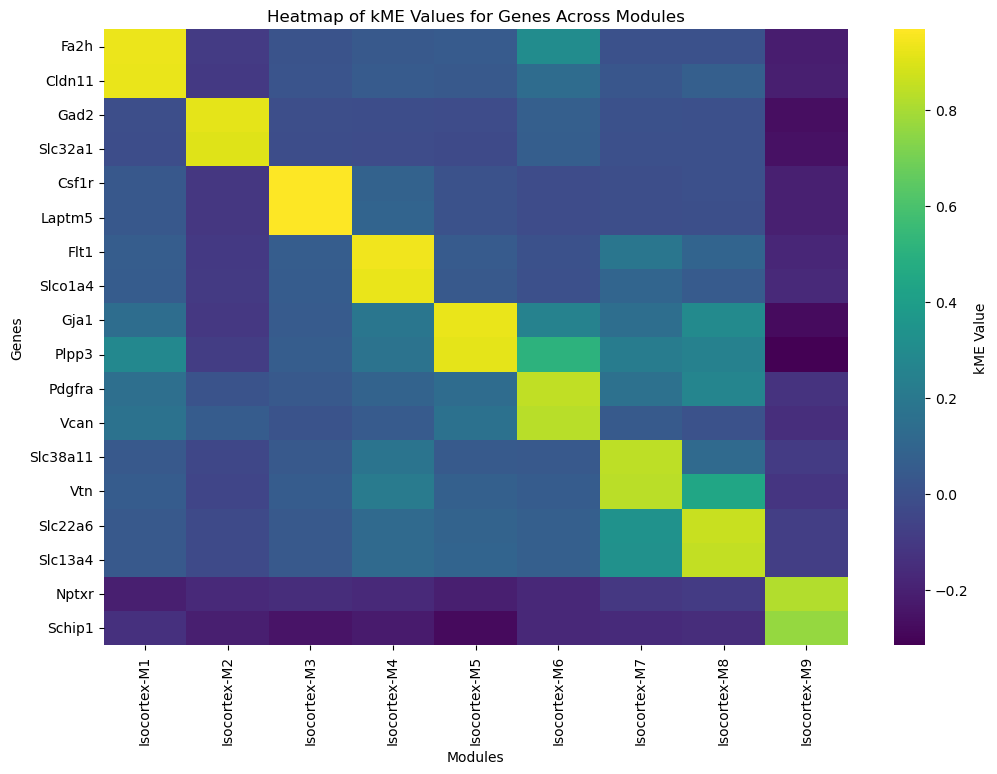

In [20]:
# Map gene IDs to gene symbols
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
heatmap_data.columns = [col.replace("kME_", "") for col in heatmap_data.columns]  # Simplify column names

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Genes Across Modules")

plt.show()

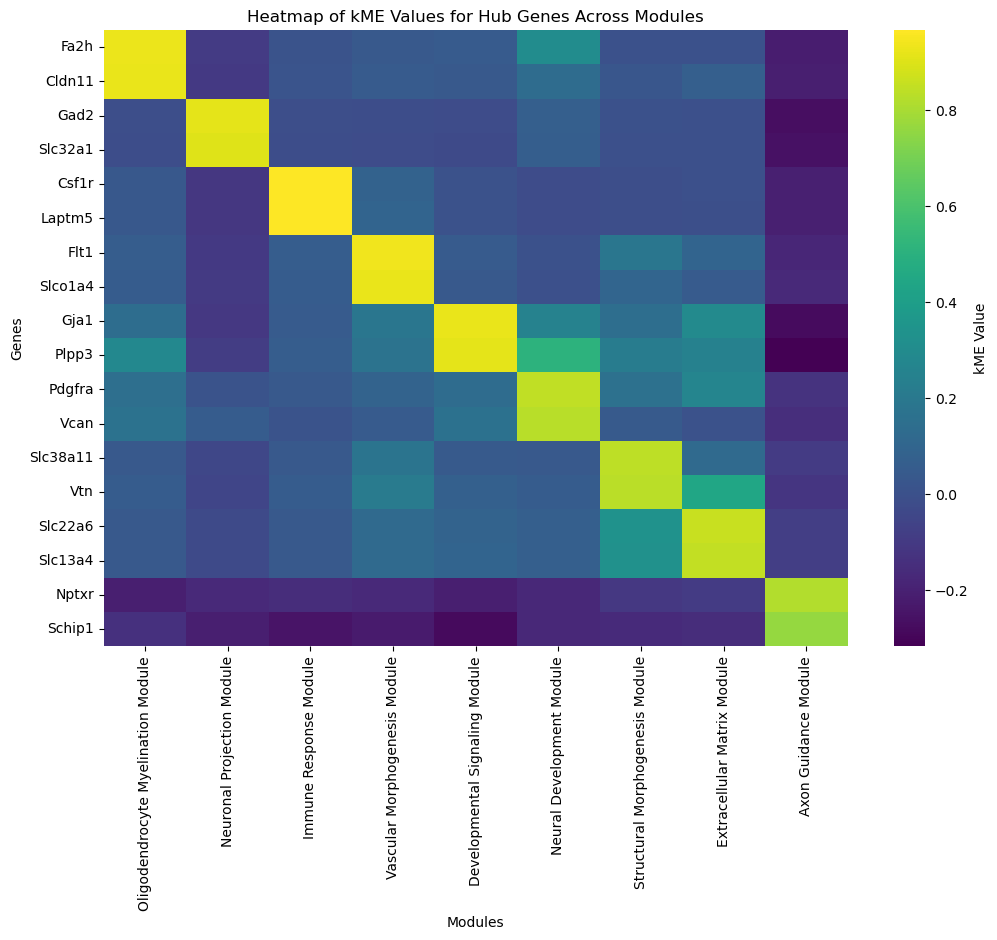

In [21]:
# Map gene IDs to gene symbols
gene_symbol_mapping = gene_names_df["gene_symbol"].to_dict()
top_genes_df["gene_symbol"] = top_genes_df["gene_name"].map(gene_symbol_mapping)

# Define a dictionary with old module names as keys and new module names as values
module_name_mapping = {
    "Isocortex-M1": "Oligodendrocyte Myelination Module",
    "Isocortex-M2": "Neuronal Projection Module",
    "Isocortex-M3": "Immune Response Module",
    "Isocortex-M4": "Vascular Morphogenesis Module",
    "Isocortex-M5": "Developmental Signaling Module",
    "Isocortex-M6": "Neural Development Module",
    "Isocortex-M7": "Structural Morphogenesis Module",
    "Isocortex-M8": "Extracellular Matrix Module",
    "Isocortex-M9": "Axon Guidance Module",
}

# Prepare the data for the heatmap
heatmap_data = top_genes_df.set_index("gene_symbol")[[f"kME_{module}" for module in top_genes_df["module"].unique()]]
heatmap_data.columns = [
    module_name_mapping.get(col.replace("kME_", ""), col.replace("kME_", ""))
    for col in heatmap_data.columns
]

# Create the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False,
    cbar_kws={"label": "kME Value"}
)

# Set axis labels and title
plt.xlabel("Modules")
plt.ylabel("Genes")
plt.title("Heatmap of kME Values for Hub Genes Across Modules")

plt.show()
